Data (X, y)
   ↓ preprocess_y
SurrogateTrainer.fit
   ↓
Grid (compute_bounds → create_nd_grid → filter_grid)
   ↓
trainer.predict → mean
pairwise_distances → std
   ↓
compute_acquisition (PI/EI/UCB, xi/kappa)
   ↓
argmax → next_query, score
   ↓
log_query_candidate
   ↓
find_best_candidate → best

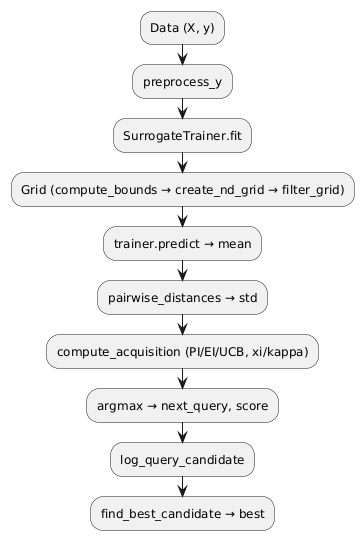

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_24714/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


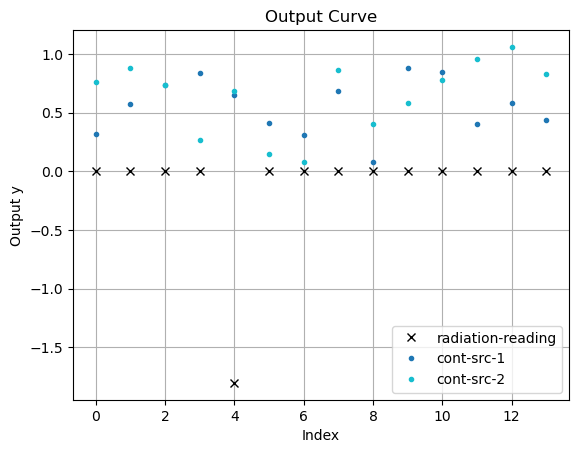

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
#row_lowest_A = df_sorted.loc[df["radiation-reading"].idxmin()]
#print(row_lowest_A)
#df_sorted.drop(df["radiation-reading"].idxmin(), inplace=True)
# Preview
#print(df_sorted)
#plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=1000, nan_marker='o')


In [4]:
X = inputs
y = outputs

In [5]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [6]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 3.0],
                                  grid_sizes=[200],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for query selection using a trained NN surrogate.
    Applies Bayesian optimisation acquisition functions (PI, EI, UCB).
    """
    global query_results
    query_results = []

    # Step 1: preprocess targets
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: train NN surrogate once
    trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)
    print("Epoch ", trainer.epochs)
    history = trainer.fit(X, y_proc, log_weights=True)
    # Plot loss curve
    plot_loss_curve(history)

    # Plot weight evolution (first layer mean)
    plot_weight_evolution(history, layer_name="model.0.weight", stat="mean")    

    # Step 3: loop over grid sizes
    for grid_size in grid_sizes:
        bounds = compute_bounds(X, margin=0.1)
        X_grid_full = create_nd_grid(bounds, grid_size)
        X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)

        if X_grid_filtered.shape[0] == 0:
            print(f"⚠️ Skipping grid_size={grid_size}, filter removed all points")
            continue

        # Step 4: predict surrogate outputs once per grid
        mean = trainer.predict(X_grid_filtered)
        
        # Step 5: uncertainty heuristic (distance to nearest training point)
        dist = pairwise_distances(X_grid_filtered, X)
        std = np.min(dist, axis=1)

        # Step 6: sweep acquisition hyperparameters
        for method in methods:
            if method in ['PI', 'EI']:
                for xi in xi_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, xi=xi)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, xi, next_query, score, mean[best_index])

            elif method == 'UCB':
                for kappa in kappa_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, kappa=kappa)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, kappa, next_query, score, mean[best_index])

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return X_grid_filtered, mean, bounds, best, query_results

Applying standard scaling to y.
Epoch  500
Epoch 1/500, Train Loss: 1.153915, Val Loss: 0.035516
Epoch 50/500, Train Loss: 0.731362, Val Loss: 0.095802
Early stopping at epoch 51, best val_loss=0.035516


/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


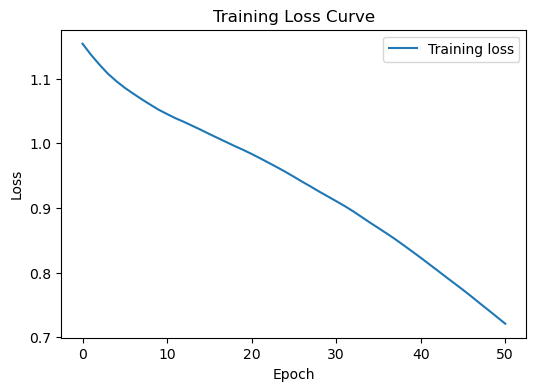

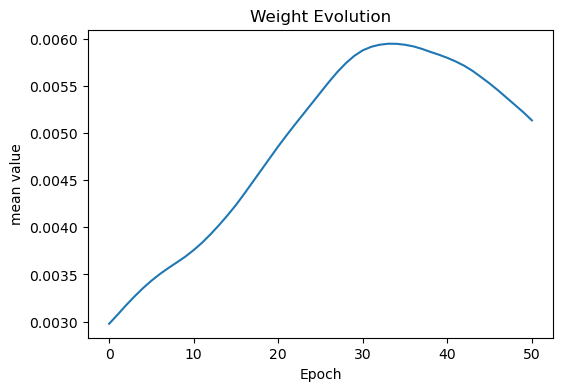

Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Using 2 dimensions.
Points before downsampling: 40000
Points after downsampling: 10000
Final grid shape: (10000, 2)
Filtering grid using mode: gp
Grid shape before filtering: (10000, 2)
Filtered 220 candidates near decision boundary (|margin| < 0.2)
Excluded 9780 candidates from consideration
Final grid shape: (220, 2)
Filtered grid shape: (220, 2)
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: UCB
Computing acquisition for method: UCB
Computing acquisition for method: UCB
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.33475238, 0.86882822]), 'score': 0.07679235984185741, 'dim': 2, 'predicted_y': 0.134

In [7]:
X_grid_filtered, mean, bounds, best, query_results = sweep_hyperparameters_NNtrain(X, y, apply_scaling=True, filter_mode='gp')

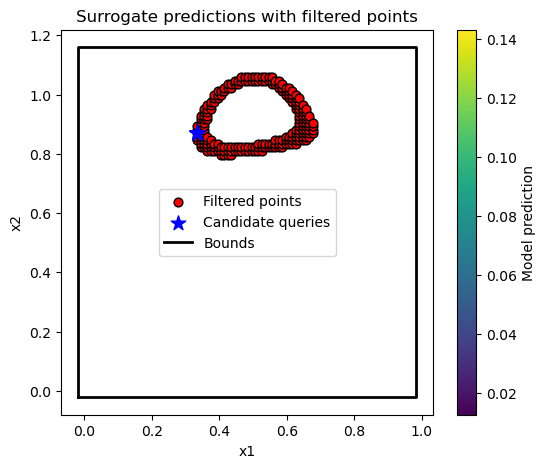

In [8]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="Surrogate predictions with filtered points")


In [9]:
print("Best Hyperparameter Configuration:")
print(best)

Best Hyperparameter Configuration:
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.33475238, 0.86882822]), 'score': 0.45562458647317794, 'dim': 2, 'predicted_y': 0.13469765}


In [10]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file
14    0.334752    0.868828       1.346976e-01  week-x
15    0.334752    0.868828       1.346976e-01  week-x
16    0.334752    0.868828       1.346976e-01  week-x
17    0.334752    0.868828  

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_24714/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


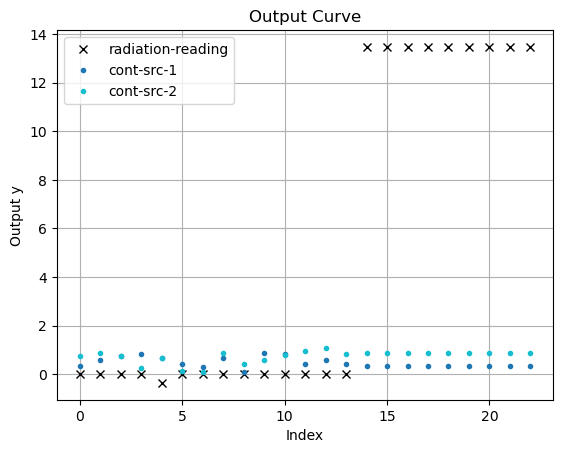

In [11]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')

In [12]:
max_val = df_sorted['radiation-reading'].max(skipna=True)
scale_factor = 10 / max_val

df_sorted['radiation-reading-scaled'] = df_sorted['radiation-reading'] * scale_factor

In [13]:
print(df_sorted)

    cont-src-1  cont-src-2  radiation-reading  source  radiation-reading-scaled
2     0.731024    0.733000       7.710875e-16    file              5.724580e-14
7     0.683418    0.861057       2.535001e-40    file              1.881994e-38
1     0.574329    0.879898       1.033078e-46    file              7.669609e-45
9     0.883890    0.582254       6.229856e-48    file              4.625067e-46
0     0.319404    0.762959       1.322677e-79    file              9.819600e-78
8     0.082507    0.403488       3.606771e-81    file              2.677679e-79
3     0.840353    0.264732      3.341771e-124    file             2.480942e-122
12    0.579291    1.059596      4.507438e-133  week-3             3.346338e-131
11    0.404040    0.959596     -9.343448e-112  week-2            -6.936608e-110
6     0.312691    0.078723      -2.089093e-91    file             -1.550950e-89
13    0.436769    0.825163      -1.519972e-55  week-4             -1.128432e-53
5     0.410437    0.147554      -2.15924